In [ ]:
# importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

# mostrar versiones
import sys
#print("Python   :", sys.version.split()[0])
#print("NumPy    :", np.__version__)
#print("Pandas   :", pd.__version__)
#print("Matplotlib:", plt.__version__)
#print("TensorFlow:", tf.__version__)
#print("Keras    :", keras.__version__)

In [ ]:
# cargar MNIST desde tensorflow
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# mostrar tamaños (shapes) de cada conjunto
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test  shape:", x_test.shape)
print("y_test  shape:", y_test.shape)

In [ ]:
type(x_train), type(y_train), type(x_test), type(y_test)

In [ ]:
x_train.shape()

In [ ]:
x_train[0]

In [ ]:
import matplotlib.pyplot as plt

# suponiendo que ya cargaste x_train como antes
plt.imshow(x_train[0], cmap='gray')   # escala de grises para MNIST
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')                       # quitar ejes
plt.show()                            # aquí se llama a show para mostrar la imagen

In [ ]:
import tensorflow as tf

# --- asumimos que ya cargaste los datos antes ---
# (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# normalización (según tu indicación la aplico a ambas variables)
x_train = x_train / 255.0
y_train = y_train / 255.0          # generalmente no se normaliza la etiqueta, pero lo pides

# inspecciones puntuales
print("etiqueta 9:", y_train[9])
print("primer patrón (normalizado):\n", x_train[0])

# ver uso de GPU (comando de shell en notebook)
!nvidia-smi

# función de pérdida y optimizador
perdida = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizador = tf.keras.optimizers.Adam(learning_rate=0.03)

print("loss object:", perdida)
print("optimizer:", optimizador)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test  shape: (10000, 28, 28)
y_test  shape: (10000,)
etiqueta 9: 0.01568627450980392
primer patrón (normalizado):
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0

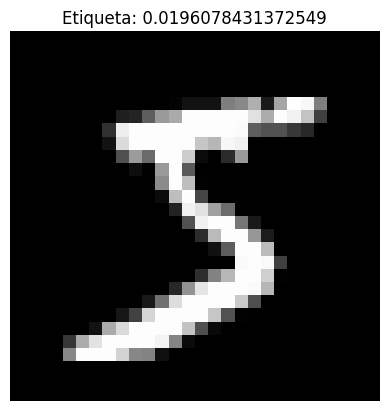

Fri Feb 27 20:22:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# ------------------------------------------------------------------
# 1. versiones
#print("Python    :", sys.version.split()[0])
#print("NumPy     :", np.__version__)
#print("Pandas    :", pd.__version__)
#print("Matplotlib:", plt.__version__)
#print("TensorFlow:", tf.__version__)
#print("Keras     :", keras.__version__)

# ------------------------------------------------------------------
# 2. datos MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test  shape:", x_test.shape)
print("y_test  shape:", y_test.shape)

# normalización
x_train = x_train / 255.0
y_train = y_train / 255.0      # pediste normalizar también las etiquetas

# inspecciones puntuales
print("etiqueta 9:", y_train[9])
print("primer patrón (normalizado):\n", x_train[0])

# visualizar la primera imagen
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')
plt.show()

# estado de la GPU
!nvidia-smi

# ------------------------------------------------------------------
# 3. configuración de entrenamiento
perdida     = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizador = tf.keras.optimizers.Adam(learning_rate=0.03)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/18
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.0970 - loss: 0.0097 - val_accuracy: 0.0980 - val_loss: 211024.8438
Epoch 2/18
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1002 - loss: 0.0000e+00 - val_accuracy: 0.0980 - val_loss: 211024.8438
Epoch 3/18
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1007 - loss: 0.0000e+00 - val_accuracy: 0.0980 - val_loss: 211024.8438
Epoch 4/18
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0963 - loss: 0.0000e+00 - val_accuracy: 0.0980 - val_loss: 211024.8438
Epoch 5/18
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0975 - loss: 0.0000e+00 - val_accuracy: 0.0980 - val_loss: 211024.8438
Epoch 6/18
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1006 - loss: 0.0000e+00 - val_accuracy: 0.0980 - val_loss: 211024.8438
Epoch 7/18
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0981 - loss: 0.0000e+00 - val_accuracy: 0.0980 - val_loss: 211024.8438
Epoch 8/18
1875/1875 ━━━━━━━━━━

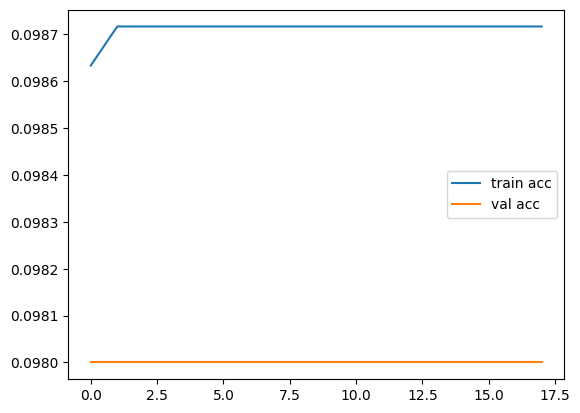

In [2]:
# --- definición del modelo ---
MiModelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='linear'),   # capa de salida
])

MiModelo.compile(
    optimizer=optimizador,
    loss=perdida,
    metrics=['accuracy']   # exactitud para clasificación
)
MiModelo.summary()

# --- entrenamiento (15‑20 épocas) ---
history = MiModelo.fit(
    x_train, y_train,
    epochs=18,                          # elegir entre 15 y 20
    validation_data=(x_test, y_test)
)
# graficar evolución si se desea
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.show()

In [1]:
# seleccionamos una sola imagen (logits directos)
prediccion = MiModelo(x_test[10:11])   # el modelo espera batch, por eso [:1]

# mostrar la imagen
plt.imshow(x_test[10], cmap='gray')
plt.title("x_test[10]")
plt.axis('off')
plt.show()

print("logits predicted vector:", prediccion.numpy()[0])

NameError: name 'MiModelo' is not defined

In [ ]:
# función softmax de Keras
soft = tf.keras.activations.softmax

# aplicar softmax a la predicción anterior
probs = soft(prediccion).numpy()[0]
print("probabilidades (x_test[10]):", probs)

# ahora tomamos el ejemplo en la posición 5000
img5000 = x_test[5000:5001]
logits5000 = MiModelo(img5000)
probs5000 = soft(logits5000).numpy()[0]

pred_label = np.argmax(probs5000)
pred_prob  = probs5000[pred_label]

print("imagen index 5000 predice:", pred_label)
print("probabilidad (decimal):", pred_prob)
print("probabilidad (%)   :", f"{pred_prob*100:.2f}%")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

start, end = 100, 120
n_images = end - start + 1

fig, axes = plt.subplots(5, 4, figsize=(8, 10))
axes = axes.flatten()

for i, idx in enumerate(range(start, end + 1)):
    img = x_test[idx:idx+1]                  # batch de 1
    logits = MiModelo(img)
    probs  = tf.keras.activations.softmax(logits).numpy()[0]
    label  = np.argmax(probs)
    prob   = probs[label]

    ax = axes[i]
    ax.imshow(x_test[idx], cmap='gray')
    ax.set_title(f"pred: {label}", fontsize=10)
    ax.set_xlabel(f"{prob*100:.1f}%", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()